In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -- STEP 1: Generate synthetic T&S catch rate --

# Imagine this is 90 days of daily catch rate on YouTube
np.random.seed(42)  # Fixes Randomness so results are reproducible

n_days = 90   # Simulating 90 days of data

In [3]:
!git --version

git version 2.34.1


In [44]:
# Normal Operations: mean 82%, std dev 3%

# Generates 90 values from a normal distribution
catch_rates = np.random.normal(loc=0.82, scale=0.03, size=n_days)

In [45]:
# Inject 3 anomaly days (a real spike scenario)

catch_rates[30] = 0.61  # bad day - classifier issue
catch_rates[60] = 0.55  # very bad day - adverserial attack
catch_rates[80] = 0.91 # unusually good day

In [46]:
# -- STEP 2: Compute Summary Statistics --

mean_rate = np.mean(catch_rates)
std_rate = np.std(catch_rates)

print(f"Mean Catch Rate:       {mean_rate:.3f}")
print(f"Standard Deviation :   {std_rate:.3f}")
print(f"Min / Max:             {catch_rates.min():.3f} / {catch_rates.max():.3f}")

Mean Catch Rate:       0.817
Standard Deviation :   0.047
Min / Max:             0.550 / 0.910


In [47]:
# -- STEP 3: Flag anomalies using 2-std-dev rule

'''
Under normal distribution, ~95% of data lies within +/- 2-sigma,
anything outside is unusual!
'''

lower_bound = mean_rate - 2 * std_rate
upper_bound = mean_rate + 2 * std_rate

anomaly_days = np.where(
    (catch_rates < lower_bound) | (catch_rates > upper_bound)
)[0]

print(f"\nAnomaly days (2-sigma rule): {anomaly_days}")
print(f"Catch rates on anomaly days: {catch_rates[anomaly_days].round(3)}")


Anomaly days (2-sigma rule): [30 60]
Catch rates on anomaly days: [0.61 0.55]


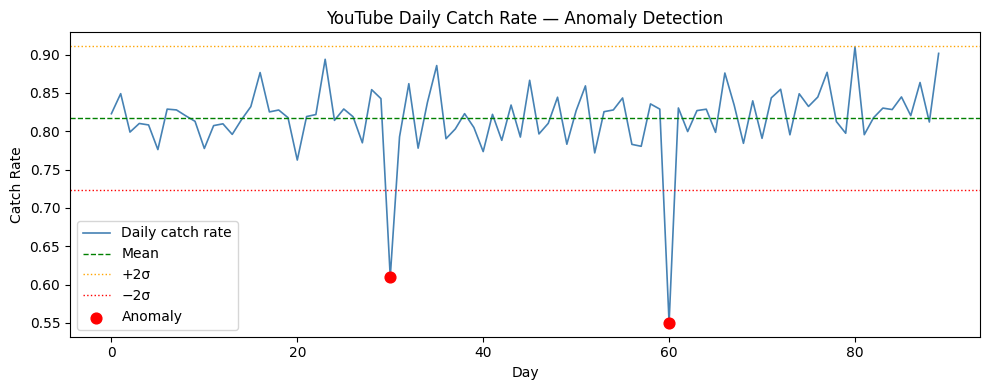

In [48]:
# -- STEP 4: Visualize --

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(catch_rates, color='steelblue', linewidth=1.2, label='Daily catch rate')
ax.axhline(mean_rate,   color='green', linestyle='--', linewidth=1, label='Mean')
ax.axhline(upper_bound, color='orange', linestyle=':', linewidth=1, label='+2σ')
ax.axhline(lower_bound, color='red',    linestyle=':', linewidth=1, label='−2σ')
ax.scatter(anomaly_days, catch_rates[anomaly_days],
           color='red', s=60, zorder=5, label='Anomaly')
ax.set_xlabel('Day')
ax.set_ylabel('Catch Rate')
ax.set_title('YouTube Daily Catch Rate — Anomaly Detection')
ax.legend()
plt.tight_layout()
plt.show()